In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data import *
from data_utils import len_active_terms, f_active_terms
from information_content import deprecated

Correspondances trouvées : 550


/home/onyxia/work/OT_simulation_maladies/Embeddings/data.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


# Statistiques descriptives sur les maladies hpoa

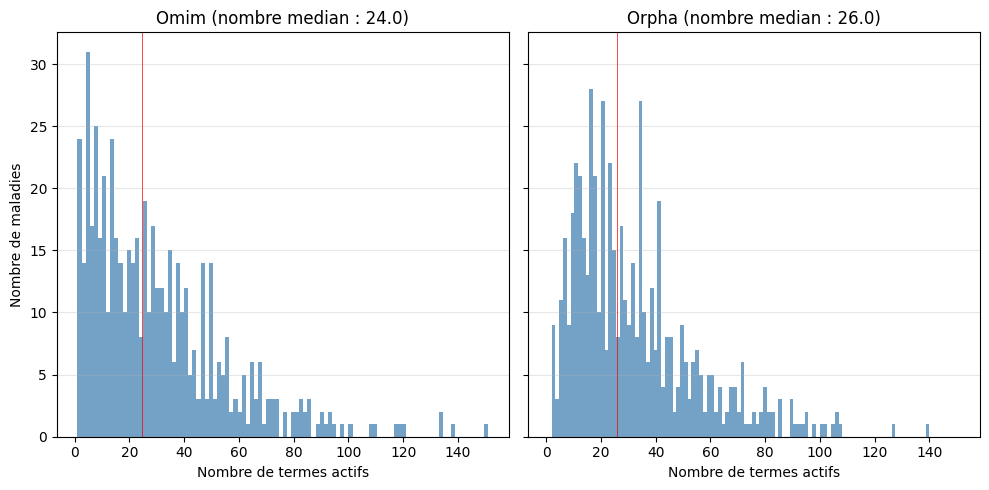

In [2]:
# Nombre moyen de termes hpo par maladie
df_omim['active terms']=df_omim.apply(len_active_terms, axis=1, args=(hpo_cols, node2id_w, deprecated))
df_orpha["active terms"]=df_orpha.apply(len_active_terms, axis=1, args=(hpo_cols, node2id_w, deprecated))

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(df_omim['active terms'], bins=100, ax=ax, color='steelblue', edgecolor='none')

ax.axvline(np.median(df_omim['active terms']), color='r', lw=0.5)
ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title(f"Omim (nombre median : {np.median(df_omim['active terms']).round(0)})")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(df_orpha['active terms'], bins=100, ax=ax, color='steelblue', edgecolor='none')

ax.axvline(np.median(df_orpha['active terms']), color='r', lw=0.5)
ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title(f"Orpha (nombre median : {np.median(df_orpha['active terms']).round(0)})")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

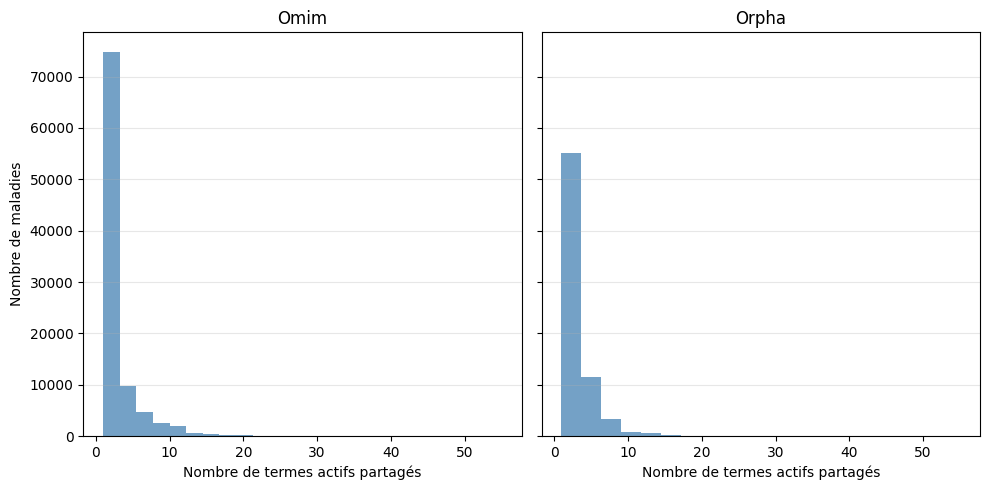

In [23]:
# Nombre de termes HPO partagés entre maladies 
df_omim['list active terms']=df_omim.apply(f_active_terms, axis=1, args=(hpo_cols, node2id_w, deprecated))
df_orpha['list active terms']=df_orpha.apply(f_active_terms, axis=1, args=(hpo_cols, node2id_w, deprecated))

def shared_active_terms(df):
    df_reset = df.reset_index(drop=True)
    n = df_reset.shape[0]
    
    all_terms = sorted(set(t for terms in df_reset['list active terms'] for t in terms))
    term_to_idx = {t: i for i, t in enumerate(all_terms)}
    p = len(all_terms)

    M = np.zeros((n, p), dtype=np.float32)
    for i, row in df_reset.iterrows():
        for t in row['list active terms']:
            M[i, term_to_idx[t]] = 1.0
    
    shared = (M @ M.T).astype(np.float32)
    np.fill_diagonal(shared, df_reset['active terms'].values)
    
    idx = np.tril_indices(n, k=-1)
    return shared, shared[idx], np.mean(shared[idx])


shared_matrix_omim, shared_omim, mean_shared_omim = shared_active_terms(df_omim)
shared_matrix_orpha, shared_orpha, mean_shared_orpha = shared_active_terms(df_orpha)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(shared_omim[shared_omim!=0], bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs partagés")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(shared_orpha[shared_orpha!=0], bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs partagés")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
print("Termes partagés : OMIM")
print(f"Max : {np.max(shared_omim)}")
print(f"Moyenne : {mean_shared_omim.round(2)}")
print(f"Pourcentage de paires sans terme commun : {np.round(len(shared_omim[shared_omim==0])/(len(shared_omim))*100, 2)}%")
print(f"Pourcentage de paires avec au moins deux termes communs : {np.round(len(shared_omim[shared_omim>1])/(len(shared_omim))*100, 2)}%")
print("Termes partagés : ORPHA")
print(f"Max : {np.max(shared_orpha)}")
print(f"Moyenne : {mean_shared_orpha.round(2)}")
print(f"Pourcentage de paires sans terme commun : {np.round(len(shared_orpha[shared_orpha==0])/(len(shared_orpha))*100, 2)}%")
print(f"Pourcentage de paires avec au moins deux termes communs : {np.round(len(shared_orpha[shared_orpha>1])/(len(shared_orpha))*100, 2)}%")

Termes partagés : OMIM
Max : 46.0
Moyenne : 1.6799999475479126
Pourcentage de paires sans terme commun : 36.76%
Pourcentage de paires avec au moins deux termes communs : 31.02%
Termes partagés : ORPHA
Max : 55.0
Moyenne : 1.2799999713897705
Pourcentage de paires sans terme commun : 52.42%
Pourcentage de paires avec au moins deux termes communs : 27.6%


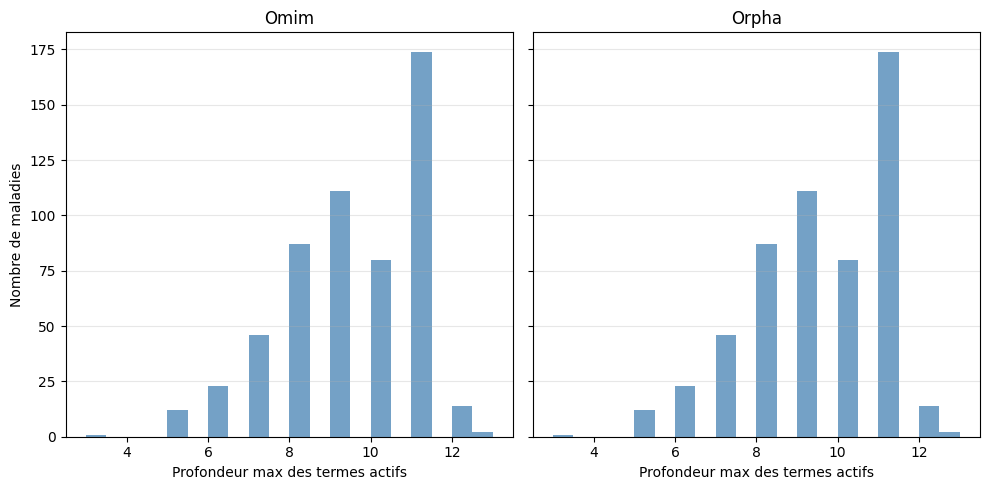

In [30]:
# Distribution de la profondeur médiane des termes pour les maladies
def depths_active_terms(df, depths):
    df_reset = df.reset_index(drop=True)
    n = df_reset.shape[0]
    
    all_terms = sorted(set(t for terms in df_reset['list active terms'] for t in terms))
    term_to_idx = {t: i for i, t in enumerate(all_terms)}
    p = len(all_terms)
    M = np.zeros((n, p), dtype=np.float32)
    for i, row in df_reset.iterrows():
        for t in row['list active terms']:
            M[i, term_to_idx[t]] = depths[t]
    return M

depths_omim = depths_active_terms(df_omim, depths)
depths_orpha = depths_active_terms(df_orpha, depths)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(np.array([np.max(row[row != 0]) for row in depths_omim]), bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Profondeur max des termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(np.array([np.max(row[row != 0]) for row in depths_omim]), bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Profondeur max des termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

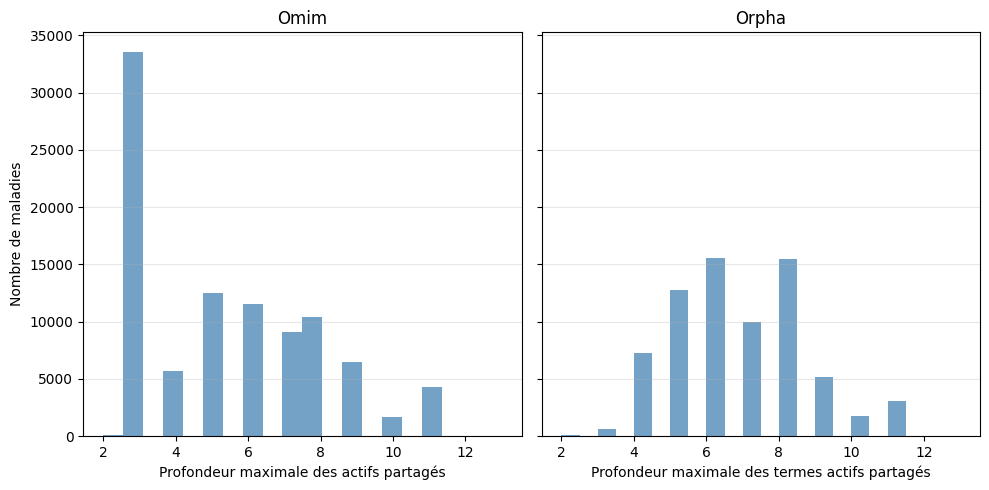

In [29]:
def max_depth_shared_terms(df, depths):
    df_reset = df.reset_index(drop=True)
    n = df_reset.shape[0]
    
    all_terms = sorted(depths.keys())
    term_to_idx = {t: i for i, t in enumerate(all_terms)}
    p = len(all_terms)
    
    # Matrice binaire (n x p)
    M = np.zeros((n, p), dtype=np.float32)
    D = np.zeros(p, dtype=np.float32)  # vecteur des profondeurs
    for i, row in df_reset.iterrows():
        for t in row['list active terms']:
            if t in term_to_idx:
                M[i, term_to_idx[t]] = 1.0
                D[term_to_idx[t]] = depths[t]
    rows, cols = np.tril_indices(n, k=-1)
    max_depths = np.array([
        np.max(D * M[rows[k]] * M[cols[k]]) if np.any(M[rows[k]] * M[cols[k]]) else 0.0
        for k in range(len(rows))
    ])
    return max_depths

max_shared_depths_omim = max_depth_shared_terms(df_omim, depths)
max_shared_depths_orpha = max_depth_shared_terms(df_orpha, depths)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(max_shared_depths_omim[max_shared_depths_omim!=0], bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Profondeur maximale des actifs partagés")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(max_shared_depths_orpha[max_shared_depths_orpha!=0], bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Profondeur maximale des termes actifs partagés")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
print("Profils OMIM")
print(f"Paires partageant des termes de profondeur au moins 4 : {np.round(len(max_shared_depths_omim[max_shared_depths_omim>3])/len(max_shared_depths_omim)*100, 2)}%")
print("Profils ORPHA")
print(f"Paires partageant des termes de profondeur au moins 4 : {np.round(len(max_shared_depths_orpha[max_shared_depths_orpha>3])/len(max_shared_depths_orpha)*100, 2)}%")

Profils OMIM
Paires partageant des termes de profondeur au moins 4 : 40.92%
Profils ORPHA
Paires partageant des termes de profondeur au moins 4 : 47.13%
